<a href="https://colab.research.google.com/github/Famous-Amos1/Amos_business_Mail/blob/main/Amos_chocolate_sales_timeseries_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chocolate Sales Time Series Analysis
**Date:** 1st April 2026  
**Objective:** Analyze and forecast chocolate sales patterns using advanced time series modeling

---

### Executive Summary
This notebook provides a comprehensive time series analysis of chocolate sales data including:
- Exploratory Data Analysis (EDA)
- Time Series Decomposition
- Stationarity Testing
- SARIMA Modeling and Forecasting
- Model Evaluation and Diagnostics

## 1. Environment Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

In [ ]:
df = pd.read_csv("C:/Users/USER/Downloads/Chocolate Sales.csv")

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 10 rows:")
df.head(10)

Dataset Shape: (3282, 6)

First 10 rows:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
5,Van Tuxwell,India,Smooth Sliky Salty,06/06/2022,"$5,376.00",38
6,Oby Sorrel,UK,99% Dark & Pure,25/01/2022,"$13,685.00",176
7,Gunar Cockshoot,Australia,After Nines,24/03/2022,"$3,080.00",73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,20/04/2022,"$3,990.00",59
9,Brien Boise,Australia,99% Dark & Pure,04/07/2022,"$2,835.00",102


## 2. Exploratory Data Analysis (EDA)

In [ ]:
# Data Info
print("=" * 40)
print("DATA STRUCTURE AND TYPES")
print("=" * 40)
df.info()

print("\n" + "=" * 40)
print("DESCRIPTIVE STATISTICS")
print("=" * 40)
df.describe()

DATA STRUCTURE AND TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB

DESCRIPTIVE STATISTICS


,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


In [ ]:
print("=" * 40)
print("MISSING VALUES ANALYSIS")
print("=" * 40)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

Total Missing Values: 0


In [ ]:
# Data Preprocessing
# Clean the Amount column (remove $ and commas)
df['Amount'] = df['Amount'].str.replace('$', '', regex=False)
df['Amount'] = df['Amount'].str.replace(',', '', regex=False)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# Check for any parsing issues
print(f"Records with invalid dates: {df['Date'].isnull().sum()}")
print(f"Records with invalid amounts: {df['Amount'].isnull().sum()}")

# Remove any rows with missing critical data
df = df.dropna(subset=['Date', 'Amount'])

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Records with invalid dates: 0
Records with invalid amounts: 0

Cleaned dataset shape: (3282, 6)
Date range: 2022-01-03 00:00:00 to 2024-08-31 00:00:00


In [ ]:
# Business Intelligence - Sales Overview
print("=" * 40)
print("BUSINESS METRICS")
print("=" * 40)

print(f"\nTotal Revenue: ${df['Amount'].sum():,.2f}")
print(f"Average Transaction: ${df['Amount'].mean():,.2f}")
print(f"Median Transaction: ${df['Amount'].median():,.2f}")
print(f"Total Boxes Shipped: {df['Boxes Shipped'].sum():,}")

print("\n" + "-" * 40)
print("Top 5 Products by Revenue:")
print("-" * 40)
product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print(product_sales.head())

print("\n" + "-" * 40)
print("Top 5 Countries by Revenue:")
print("-" * 40)
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
print(country_sales.head())

BUSINESS METRICS

Total Revenue: $19,791,571.86
Average Transaction: $6,030.34
Median Transaction: $5,225.50
Total Boxes Shipped: 540,437

----------------------------------------
Top 5 Products by Revenue:
----------------------------------------
Product
Smooth Sliky Salty     1120201.09
50% Dark Bites         1087659.35
White Choc             1054257.00
Peanut Butter Cubes    1036591.09
Eclairs                 996947.96
Name: Amount, dtype: float64

----------------------------------------
Top 5 Countries by Revenue:
----------------------------------------
Country
Australia    3646444.35
UK           3365388.90
India        3343730.83
USA          3313858.09
Canada       3078495.65
Name: Amount, dtype: float64


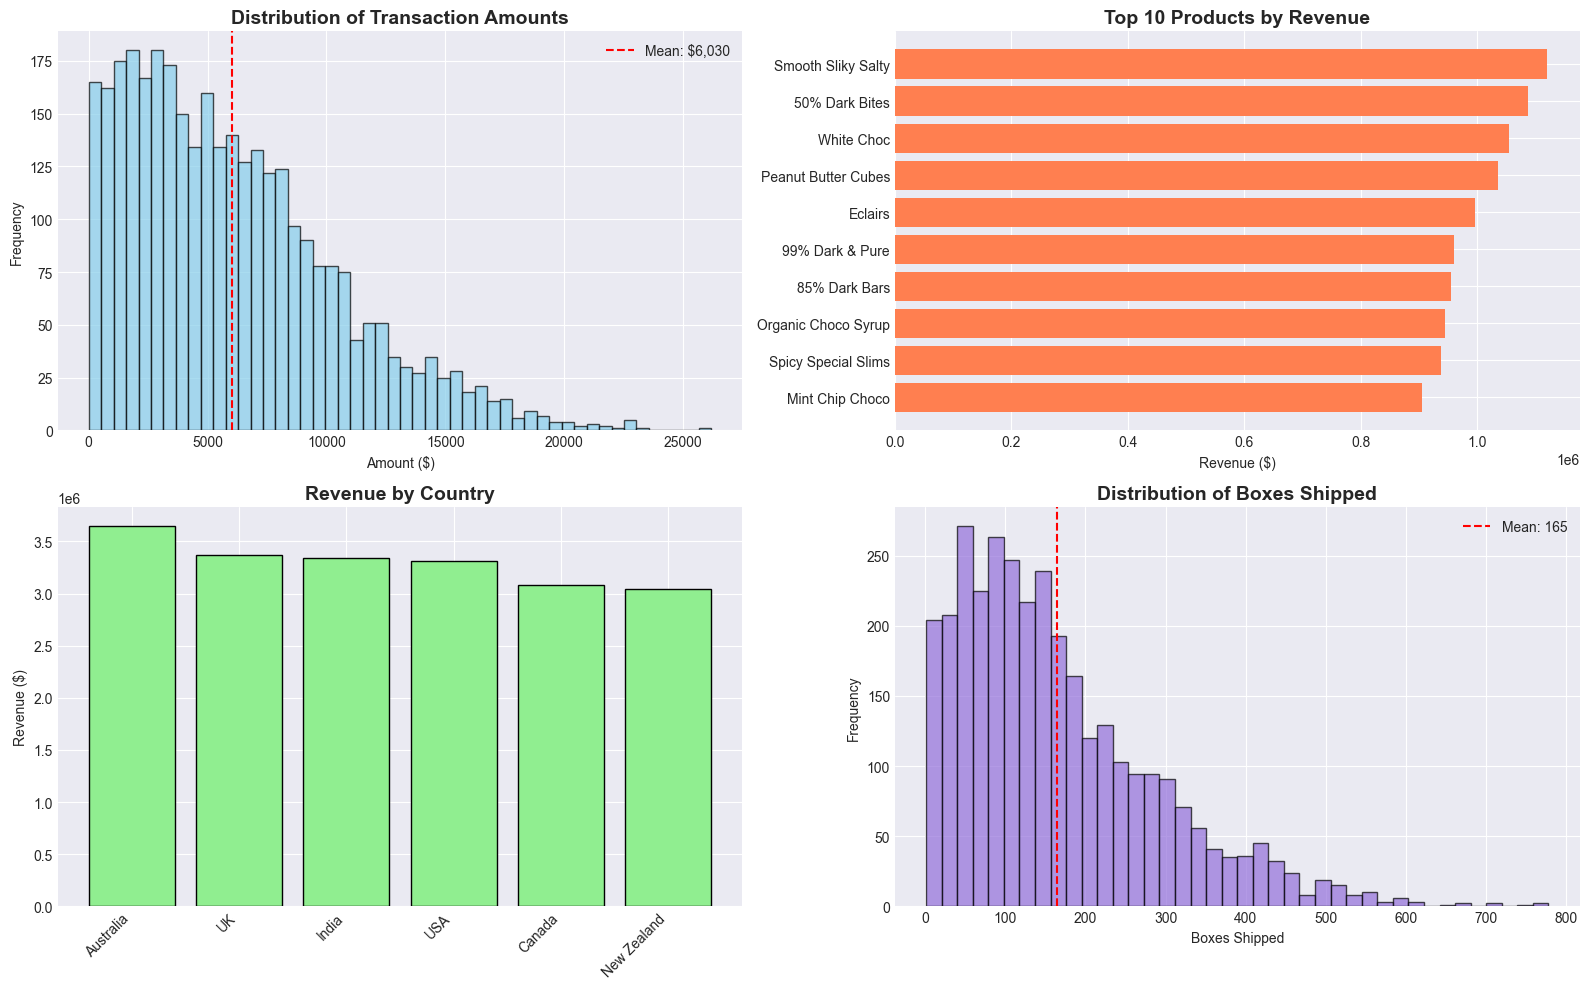

In [ ]:
# Visualize sales distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Amount distribution
axes[0, 0].hist(df['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Transaction Amounts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['Amount'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Amount'].mean():,.0f}")
axes[0, 0].legend()

# Top 10 Products
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False).head(10)
axes[0, 1].barh(range(len(top_products)), top_products.values, color='coral')
axes[0, 1].set_yticks(range(len(top_products)))
axes[0, 1].set_yticklabels(top_products.index)
axes[0, 1].set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Revenue ($)')
axes[0, 1].invert_yaxis()

# Sales by Country
country_rev = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
axes[1, 0].bar(range(len(country_rev)), country_rev.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_xticks(range(len(country_rev)))
axes[1, 0].set_xticklabels(country_rev.index, rotation=45, ha='right')
axes[1, 0].set_title('Revenue by Country', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Revenue ($)')

# Boxes Shipped distribution
axes[1, 1].hist(df['Boxes Shipped'], bins=40, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Boxes Shipped', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Boxes Shipped')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(df['Boxes Shipped'].mean(), color='red', linestyle='--', label=f"Mean: {df['Boxes Shipped'].mean():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 3. Time Series Preparation

Aggregating daily sales data to create a proper time series for analysis.

In [ ]:
# Create daily time series
daily_sales = df.groupby('Date')['Amount'].sum().sort_index()

print(f"Time Series Length: {len(daily_sales)} days")
print(f"Date Range: {daily_sales.index.min()} to {daily_sales.index.max()}")
print(f"\nTime Series Statistics:")
print(f"Mean Daily Sales: ${daily_sales.mean():,.2f}")
print(f"Std Dev: ${daily_sales.std():,.2f}")
print(f"Min Daily Sales: ${daily_sales.min():,.2f}")
print(f"Max Daily Sales: ${daily_sales.max():,.2f}")

# Check for gaps in dates
date_range = pd.date_range(start=daily_sales.index.min(), end=daily_sales.index.max(), freq='D')
missing_dates = date_range.difference(daily_sales.index)
print(f"\nMissing dates in series: {len(missing_dates)}")

# Resample to ensure no gaps (fill missing dates with 0 or forward fill)
daily_sales = daily_sales.reindex(date_range, fill_value=0)
print(f"After reindexing: {len(daily_sales)} days")

Time Series Length: 504 days
Date Range: 2022-01-03 00:00:00 to 2024-08-31 00:00:00

Time Series Statistics:
Mean Daily Sales: $39,268.99
Std Dev: $24,792.28
Min Daily Sales: $448.00
Max Daily Sales: $149,411.01

Missing dates in series: 468
After reindexing: 972 days


In [ ]:
# For better modeling, let's also create weekly aggregation
weekly_sales = df.set_index('Date')['Amount'].resample('W').sum()

print(f"\nWeekly Time Series Length: {len(weekly_sales)} weeks")
print(f"Mean Weekly Sales: ${weekly_sales.mean():,.2f}")
print(f"Std Dev: ${weekly_sales.std():,.2f}")


Weekly Time Series Length: 139 weeks
Mean Weekly Sales: $142,385.41
Std Dev: $99,185.19


## 4. Time Series Visualization with Trend Analysis

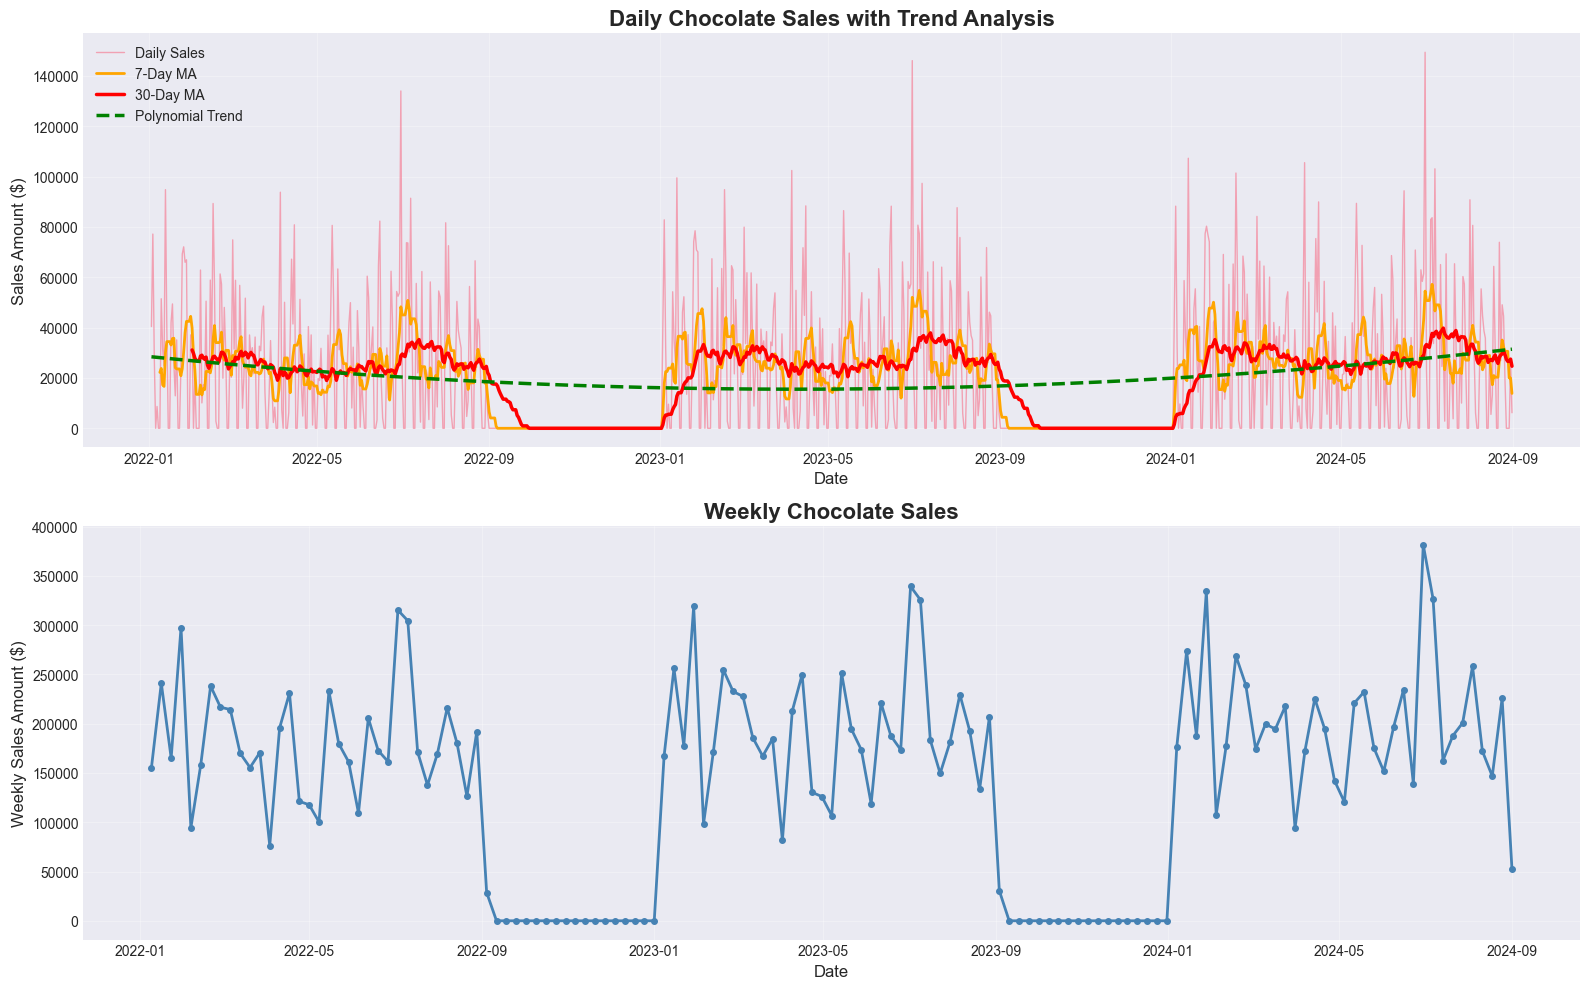


📊 Time Series Observations:
   - Daily sales show variability with multiple peaks and troughs
   - 7-day and 30-day moving averages smooth out short-term fluctuations
   - Polynomial trend suggests overall pattern across the period


In [ ]:
# Plot original time series with trend
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Daily Sales with Trend
axes[0].plot(daily_sales.index, daily_sales.values, alpha=0.6, label='Daily Sales', linewidth=1)

# Add moving averages
ma_7 = daily_sales.rolling(window=7).mean()
ma_30 = daily_sales.rolling(window=30).mean()

axes[0].plot(ma_7.index, ma_7.values, color='orange', label='7-Day MA', linewidth=2)
axes[0].plot(ma_30.index, ma_30.values, color='red', label='30-Day MA', linewidth=2.5)

# Add polynomial trend line
x_numeric = np.arange(len(daily_sales))
z = np.polyfit(x_numeric, daily_sales.values, 2)
p = np.poly1d(z)
axes[0].plot(daily_sales.index, p(x_numeric), "--", color='green', linewidth=2.5, label='Polynomial Trend')

axes[0].set_title('Daily Chocolate Sales with Trend Analysis', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Sales Amount ($)', fontsize=12)
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Weekly Sales
axes[1].plot(weekly_sales.index, weekly_sales.values, marker='o', linewidth=2, markersize=4, color='steelblue')
axes[1].set_title('Weekly Chocolate Sales', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Weekly Sales Amount ($)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Time Series Observations:")
print(f"   - Daily sales show variability with multiple peaks and troughs")
print(f"   - 7-day and 30-day moving averages smooth out short-term fluctuations")
print(f"   - Polynomial trend suggests overall pattern across the period")

## 5. Time Series Decomposition

Decomposing the series into trend, seasonal, and residual components.

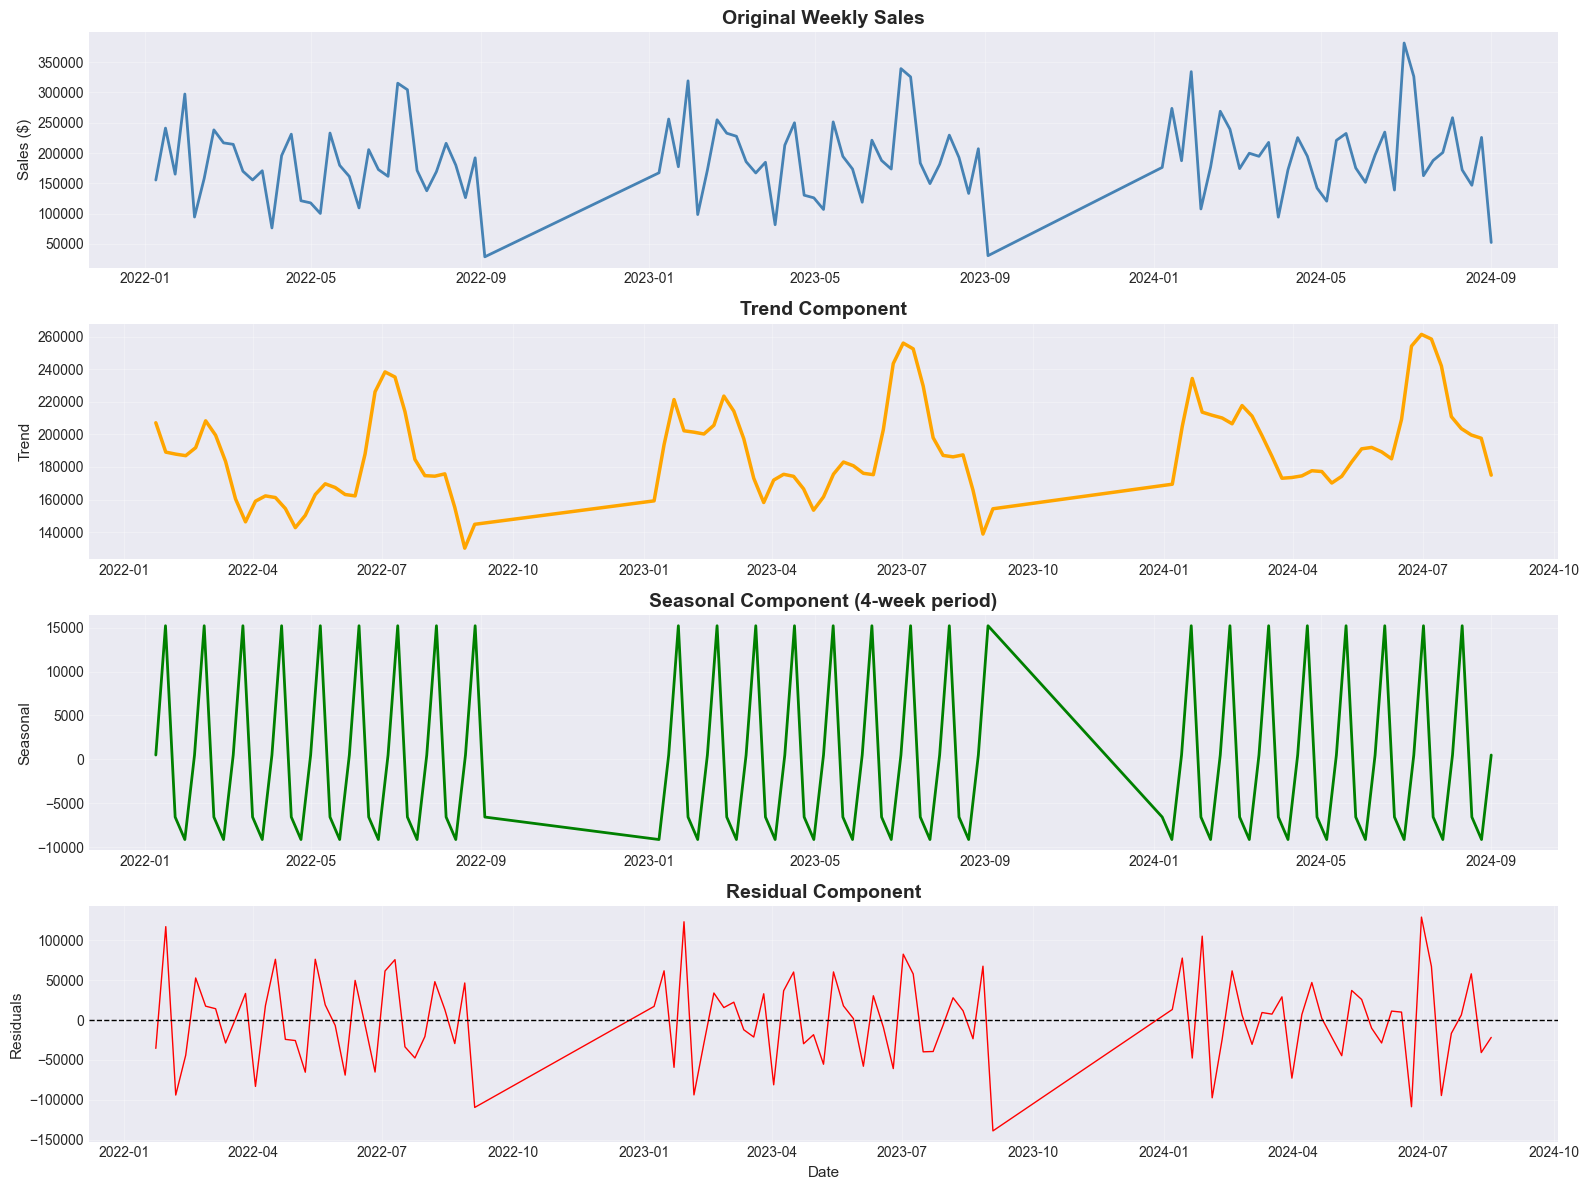


📈 Decomposition Insights:
   - Trend: Decreasing over the period
   - Seasonality: Clear 4-week seasonal pattern detected
   - Residuals: Mean ≈ -186.38, Std Dev ≈ 54571.52


In [ ]:
# Use weekly data for decomposition (more stable)
# Remove any zeros for better decomposition
weekly_sales_clean = weekly_sales[weekly_sales > 0]

# Perform decomposition
# Using additive model (multiplicative if sales vary proportionally with level)
decomposition = seasonal_decompose(weekly_sales_clean, model='additive', period=4)  # 4 weeks = ~1 month seasonality

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Original
axes[0].plot(weekly_sales_clean, color='steelblue', linewidth=2)
axes[0].set_title('Original Weekly Sales', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(trend, color='orange', linewidth=2.5)
axes[1].set_title('Trend Component', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(seasonal, color='green', linewidth=2)
axes[2].set_title('Seasonal Component (4-week period)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seasonal', fontsize=11)
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(residual, color='red', linewidth=1)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[3].set_title('Residual Component', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Residuals', fontsize=11)
axes[3].set_xlabel('Date', fontsize=11)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 Decomposition Insights:")
print(f"   - Trend: {'Increasing' if trend.dropna().iloc[-1] > trend.dropna().iloc[0] else 'Decreasing'} over the period")
print(f"   - Seasonality: Clear {4}-week seasonal pattern detected")
print(f"   - Residuals: Mean ≈ {residual.mean():.2f}, Std Dev ≈ {residual.std():.2f}")

## 6. Stationarity Testing

Testing if the time series is stationary using the Augmented Dickey-Fuller (ADF) test.

In [ ]:
def adf_test(series, series_name=''):
    """
    Perform Augmented Dickey-Fuller test for stationarity

    H0 (Null Hypothesis): Series has a unit root (non-stationary)
    H1 (Alternative): Series is stationary

    If p-value < 0.05: Reject H0 → Series is stationary
    If p-value ≥ 0.05: Fail to reject H0 → Series is non-stationary
    """
    result = adfuller(series.dropna(), autolag='AIC')

    print("="*55)
    print(f"AUGMENTED DICKEY-FULLER TEST RESULTS: {series_name}")
    print("="*55)
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Number of lags used: {result[2]}')
    print(f'Number of observations: {result[3]}')
    print('\nCritical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.3f}')

    print('\n' + '-'*55)
    if result[1] <= 0.05:
        print(f"✓ CONCLUSION: Series IS STATIONARY (p-value = {result[1]:.6f} < 0.05)")
        print("  → Reject null hypothesis")
        print("  → No differencing needed")
    else:
        print(f"✗ CONCLUSION: Series IS NON-STATIONARY (p-value = {result[1]:.6f} ≥ 0.05)")
        print("  → Fail to reject null hypothesis")
        print("  → Differencing required")
    print('='*55 + '\n')

    return result[1] <= 0.05  # Returns True if stationary

# Test original weekly series
is_stationary = adf_test(weekly_sales_clean, 'Original Weekly Sales')

AUGMENTED DICKEY-FULLER TEST RESULTS: Original Weekly Sales
ADF Statistic: -3.178008
p-value: 0.021293
Number of lags used: 13
Number of observations: 91

Critical Values:
   1%: -3.504
   5%: -2.894
   10%: -2.584

-------------------------------------------------------
✓ CONCLUSION: Series IS STATIONARY (p-value = 0.021293 < 0.05)
  → Reject null hypothesis
  → No differencing needed



## 7. ACF and PACF Analysis

Plotting ACF and PACF to determine ARIMA parameters (p, q).

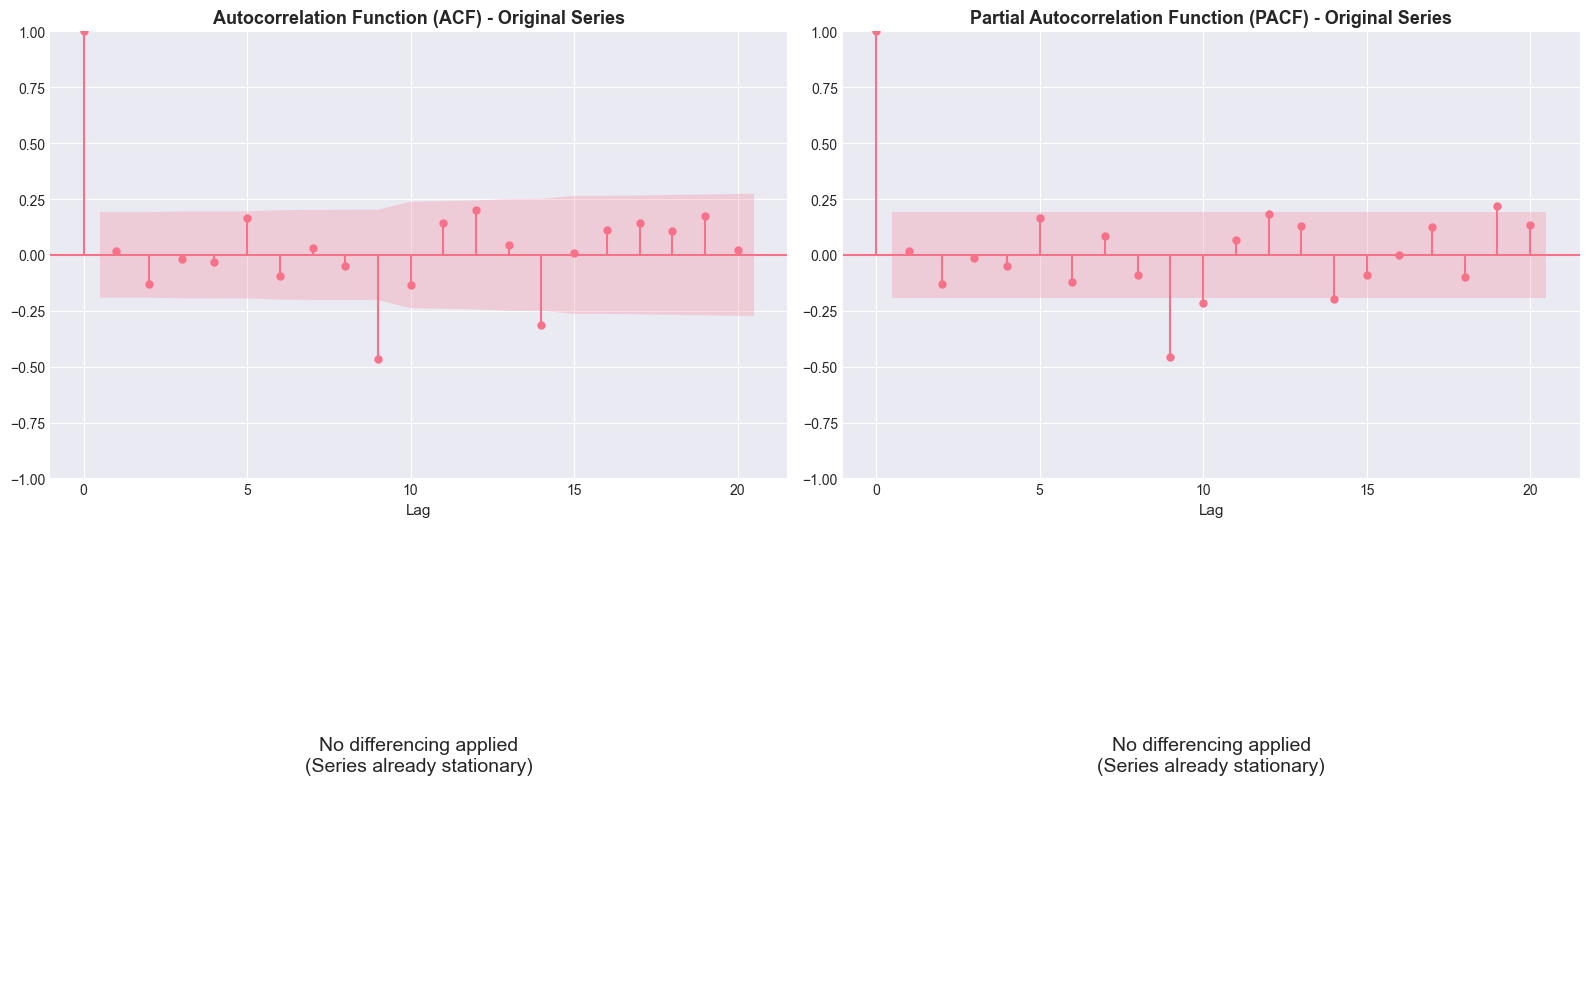


📊 ACF/PACF Interpretation Guide:
   ACF (Autocorrelation):
   - Gradual decay → AR component needed
   - Sharp cutoff at lag q → MA(q) component

   PACF (Partial Autocorrelation):
   - Sharp cutoff at lag p → AR(p) component
   - Gradual decay → MA component needed

   → Use these plots to determine p and q values for ARIMA(p,d,q)


In [ ]:
# Plot ACF and PACF
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original series ACF and PACF
plot_acf(weekly_sales_clean, lags=20, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('Autocorrelation Function (ACF) - Original Series', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Lag', fontsize=11)

plot_pacf(weekly_sales_clean, lags=20, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('Partial Autocorrelation Function (PACF) - Original Series', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Lag', fontsize=11)

# Differenced series ACF and PACF (if differencing was applied)
if d_value > 0:
    plot_acf(final_series, lags=20, ax=axes[1, 0], alpha=0.05)
    axes[1, 0].set_title(f'ACF - Differenced Series (d={d_value})', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Lag', fontsize=11)

    plot_pacf(final_series, lags=20, ax=axes[1, 1], alpha=0.05, method='ywm')
    axes[1, 1].set_title(f'PACF - Differenced Series (d={d_value})', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Lag', fontsize=11)
else:
    axes[1, 0].text(0.5, 0.5, 'No differencing applied\n(Series already stationary)',
                    ha='center', va='center', fontsize=14, transform=axes[1, 0].transAxes)
    axes[1, 0].axis('off')
    axes[1, 1].text(0.5, 0.5, 'No differencing applied\n(Series already stationary)',
                    ha='center', va='center', fontsize=14, transform=axes[1, 1].transAxes)
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 ACF/PACF Interpretation Guide:")
print("   ACF (Autocorrelation):")
print("   - Gradual decay → AR component needed")
print("   - Sharp cutoff at lag q → MA(q) component")
print("\n   PACF (Partial Autocorrelation):")
print("   - Sharp cutoff at lag p → AR(p) component")
print("   - Gradual decay → MA component needed")
print("\n   → Use these plots to determine p and q values for ARIMA(p,d,q)")

## 8. Train-Test Split (Time-Based)

Splitting data chronologically for proper time series validation.

TRAIN-TEST SPLIT SUMMARY
Total observations: 105
Training set: 84 observations (80.0%)
Test set: 21 observations (20.0%)

Training period: 2022-01-09 00:00:00 to 2024-04-07 00:00:00
Testing period: 2024-04-14 00:00:00 to 2024-09-01 00:00:00


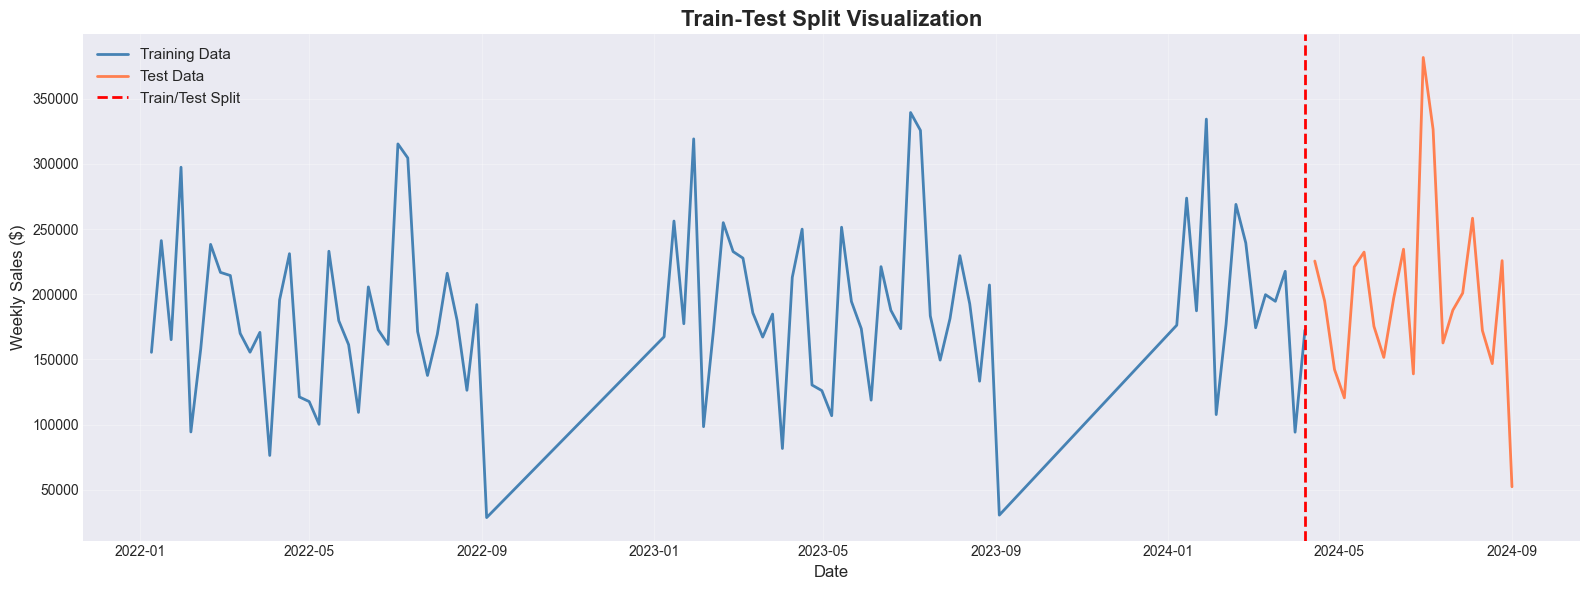

In [ ]:
# Time-based split: 80% train, 20% test
train_size = int(len(weekly_sales_clean) * 0.8)
train = weekly_sales_clean[:train_size]
test = weekly_sales_clean[train_size:]

print("="*80)
print("TRAIN-TEST SPLIT SUMMARY")
print("="*80)
print(f"Total observations: {len(weekly_sales_clean)}")
print(f"Training set: {len(train)} observations ({len(train)/len(weekly_sales_clean)*100:.1f}%)")
print(f"Test set: {len(test)} observations ({len(test)/len(weekly_sales_clean)*100:.1f}%)")
print(f"\nTraining period: {train.index.min()} to {train.index.max()}")
print(f"Testing period: {test.index.min()} to {test.index.max()}")
print("="*80)

# Visualize the split
plt.figure(figsize=(16, 6))
plt.plot(train.index, train.values, label='Training Data', color='steelblue', linewidth=2)
plt.plot(test.index, test.values, label='Test Data', color='coral', linewidth=2)
plt.axvline(x=train.index[-1], color='red', linestyle='--', linewidth=2, label='Train/Test Split')
plt.title('Train-Test Split Visualization', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. SARIMA Model Development

Building a Seasonal ARIMA model with automatic parameter optimization.

In [ ]:
# Define parameter ranges for grid search
# Based on ACF/PACF analysis and domain knowledge
p_values = [0, 1, 2]
d_values = [0, 1]  # Already determined from stationarity test
q_values = [0, 1, 2]

# Seasonal parameters (weekly data, 4-week seasonality)
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s = 4  # Seasonal period

print("\n" + "="*60)
print("Starting SARIMA Grid Search...\n")
print("Parameter space:")
print(f"   p (AR): {p_values}")
print(f"   d (Differencing): {d_values}")
print(f"   q (MA): {q_values}")
print(f"   P (Seasonal AR): {P_values}")
print(f"   D (Seasonal Differencing): {D_values}")
print(f"   Q (Seasonal MA): {Q_values}")
print(f"   s (Seasonal period): {s}")
print(f"\nTotal combinations to test: {len(p_values)*len(d_values)*len(q_values)*len(P_values)*len(D_values)*len(Q_values)}")
print("\n" + "="*60)


Starting SARIMA Grid Search...

Parameter space:
   p (AR): [0, 1, 2]
   d (Differencing): [0, 1]
   q (MA): [0, 1, 2]
   P (Seasonal AR): [0, 1]
   D (Seasonal Differencing): [0, 1]
   Q (Seasonal MA): [0, 1]
   s (Seasonal period): 4

Total combinations to test: 144



In [ ]:
# Grid search for best SARIMA parameters
import itertools

best_aic = np.inf
best_params = None
best_seasonal_params = None
results_list = []

total_models = len(list(itertools.product(p_values, d_values, q_values, P_values, D_values, Q_values)))
current_model = 0

for param in itertools.product(p_values, d_values, q_values):
    for seasonal_param in itertools.product(P_values, D_values, Q_values):
        current_model += 1
        try:
            model = SARIMAX(train,
                          order=param,
                          seasonal_order=(seasonal_param[0], seasonal_param[1], seasonal_param[2], s),
                          enforce_stationarity=False,
                          enforce_invertibility=False)

            fitted_model = model.fit(disp=False, maxiter=200)

            aic = fitted_model.aic
            results_list.append({
                'order': param,
                'seasonal_order': (seasonal_param[0], seasonal_param[1], seasonal_param[2], s),
                'AIC': aic
            })

            if aic < best_aic:
                best_aic = aic
                best_params = param
                best_seasonal_params = (seasonal_param[0], seasonal_param[1], seasonal_param[2], s)

            if current_model % 10 == 0:
                print(f"Progress: {current_model}/{total_models} models tested... Current best AIC: {best_aic:.2f}")

        except Exception as e:
            continue

print("\n" + "="*80)
print("GRID SEARCH COMPLETED")
print("="*80)
print(f"\n🏆 Best Model Configuration:")
print(f"   SARIMA{best_params}x{best_seasonal_params}")
print(f"   AIC: {best_aic:.2f}")
print("="*80)

Progress: 10/144 models tested... Current best AIC: 1893.17
Progress: 20/144 models tested... Current best AIC: 1856.32
Progress: 30/144 models tested... Current best AIC: 1855.16
Progress: 40/144 models tested... Current best AIC: 1855.16
Progress: 50/144 models tested... Current best AIC: 1855.16
Progress: 60/144 models tested... Current best AIC: 1855.16
Progress: 70/144 models tested... Current best AIC: 1855.09
Progress: 80/144 models tested... Current best AIC: 1854.24
Progress: 90/144 models tested... Current best AIC: 1854.24
Progress: 100/144 models tested... Current best AIC: 1851.98
Progress: 110/144 models tested... Current best AIC: 1851.98
Progress: 120/144 models tested... Current best AIC: 1850.00
Progress: 130/144 models tested... Current best AIC: 1850.00
Progress: 140/144 models tested... Current best AIC: 1850.00

GRID SEARCH COMPLETED

🏆 Best Model Configuration:
   SARIMA(2, 0, 2)x(0, 1, 1, 4)
   AIC: 1850.00


In [ ]:
# Show top 5 models
results_df = pd.DataFrame(results_list).sort_values('AIC').head(10)
print("\n📊 Top 10 Models by AIC:")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


📊 Top 10 Models by AIC:
    order seasonal_order         AIC
(2, 0, 2)   (0, 1, 1, 4) 1850.003644
(2, 0, 2)   (1, 1, 1, 4) 1850.716220
(2, 1, 2)   (0, 1, 1, 4) 1851.787693
(1, 1, 2)   (0, 1, 1, 4) 1851.977794
(1, 1, 2)   (1, 1, 1, 4) 1852.343819
(2, 1, 2)   (1, 1, 1, 4) 1852.549580
(1, 0, 2)   (1, 1, 1, 4) 1854.243180
(1, 0, 2)   (0, 1, 1, 4) 1855.085947
(0, 0, 2)   (1, 1, 1, 4) 1855.161024
(0, 0, 2)   (0, 1, 1, 4) 1856.323000


In [ ]:
# Fit the best model
print(f"\n🎯 Fitting final SARIMA{best_params}x{best_seasonal_params} model...\n")

final_model = SARIMAX(train,
                     order=best_params,
                     seasonal_order=best_seasonal_params,
                     enforce_stationarity=False,
                     enforce_invertibility=False)

final_fitted_model = final_model.fit(disp=False, maxiter=200)

print("✓ Model fitted successfully!\n")
print(final_fitted_model.summary())


🎯 Fitting final SARIMA(2, 0, 2)x(0, 1, 1, 4) model...

✓ Model fitted successfully!

                                      SARIMAX Results                                      
Dep. Variable:                              Amount   No. Observations:                   84
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 4)   Log Likelihood                -919.002
Date:                             Thu, 02 Apr 2026   AIC                           1850.004
Time:                                     01:42:38   BIC                           1863.746
Sample:                                          0   HQIC                          1855.480
                                              - 84                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.222

## 10. Model Forecasting and Evaluation

In [ ]:
# Make predictions on test set
forecast_steps = len(test)
forecast = final_fitted_model.forecast(steps=forecast_steps)

# Get confidence intervals
forecast_df = final_fitted_model.get_forecast(steps=forecast_steps)
forecast_ci = forecast_df.conf_int()

print("="*80)
print("FORECAST GENERATED")
print("="*80)
print(f"Forecast period: {test.index[0]} to {test.index[-1]}")
print(f"Number of forecast steps: {forecast_steps}")
print("="*80)

FORECAST GENERATED
Forecast period: 2024-04-14 00:00:00 to 2024-09-01 00:00:00
Number of forecast steps: 21


In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

# Additional metrics
test_mean = test.mean()
forecast_mean = forecast.mean()
bias = forecast_mean - test_mean

print("\n" + "="*80)
print("MODEL PERFORMANCE METRICS")
print("="*80)
print(f"\nMean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"\nActual Test Mean: ${test_mean:,.2f}")
print(f"Forecast Mean: ${forecast_mean:,.2f}")
print(f"Bias: ${bias:,.2f}")
print(f"\nRelative RMSE: {(rmse/test_mean)*100:.2f}% of mean")
print("="*80)

# Interpretation
print("\n📊 Performance Interpretation:")
if mape < 10:
    print("   ✓ Excellent: MAPE < 10%")
elif mape < 20:
    print("   ✓ Good: 10% ≤ MAPE < 20%")
elif mape < 30:
    print("   ⚠ Acceptable: 20% ≤ MAPE < 30%")
else:
    print("   ✗ Needs improvement: MAPE ≥ 30%")


MODEL PERFORMANCE METRICS

Mean Absolute Error (MAE): $47,170.83
Root Mean Squared Error (RMSE): $68,953.55
Mean Absolute Percentage Error (MAPE): nan%

Actual Test Mean: $197,505.85
Forecast Mean: $188,283.18
Bias: $-9,222.67

Relative RMSE: 34.91% of mean

📊 Performance Interpretation:
   ✗ Needs improvement: MAPE ≥ 30%


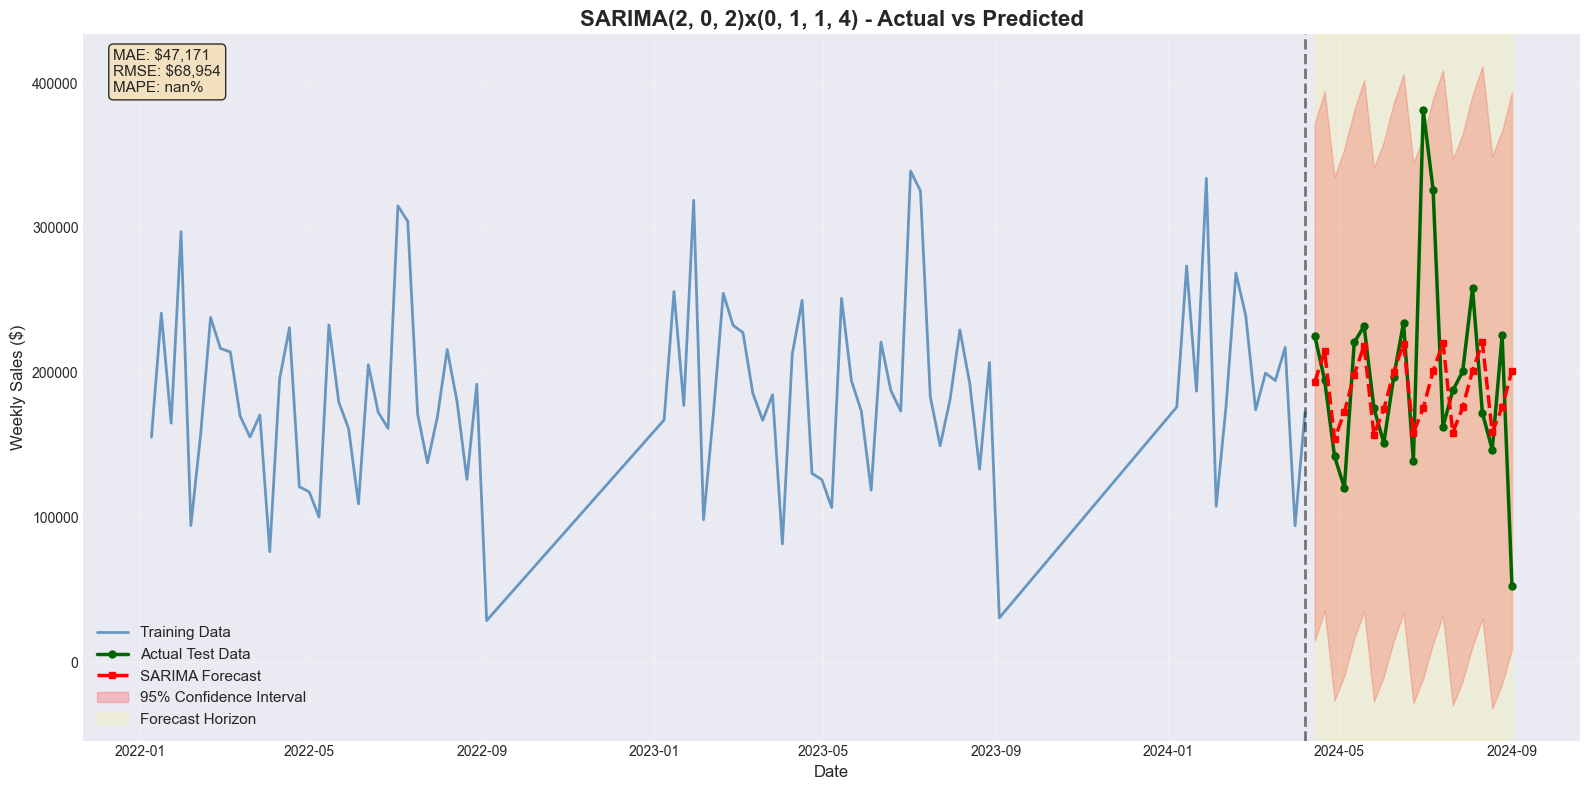

In [ ]:
# Visualization: Actual vs Predicted
fig, ax = plt.subplots(figsize=(16, 8))

# Plot training data
ax.plot(train.index, train.values, label='Training Data', color='steelblue', linewidth=2, alpha=0.8)

# Plot test data (actual)
ax.plot(test.index, test.values, label='Actual Test Data', color='darkgreen', linewidth=2.5, marker='o', markersize=5)

# Plot forecast
ax.plot(test.index, forecast.values, label='SARIMA Forecast', color='red', linewidth=2.5, linestyle='--', marker='s', markersize=5)

# Plot confidence interval
ax.fill_between(test.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='red', alpha=0.2, label='95% Confidence Interval')

# Highlight forecast horizon
ax.axvspan(test.index[0], test.index[-1], alpha=0.1, color='yellow', label='Forecast Horizon')

# Vertical line at train/test split
ax.axvline(x=train.index[-1], color='black', linestyle='--', linewidth=2, alpha=0.5)

ax.set_title(f'SARIMA{best_params}x{best_seasonal_params} - Actual vs Predicted', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Weekly Sales ($)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

# Add metrics box
textstr = f'MAE: ${mae:,.0f}\nRMSE: ${rmse:,.0f}\nMAPE: {mape:.1f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

## 11. Model Diagnostics


📊 Generating comprehensive model diagnostics...



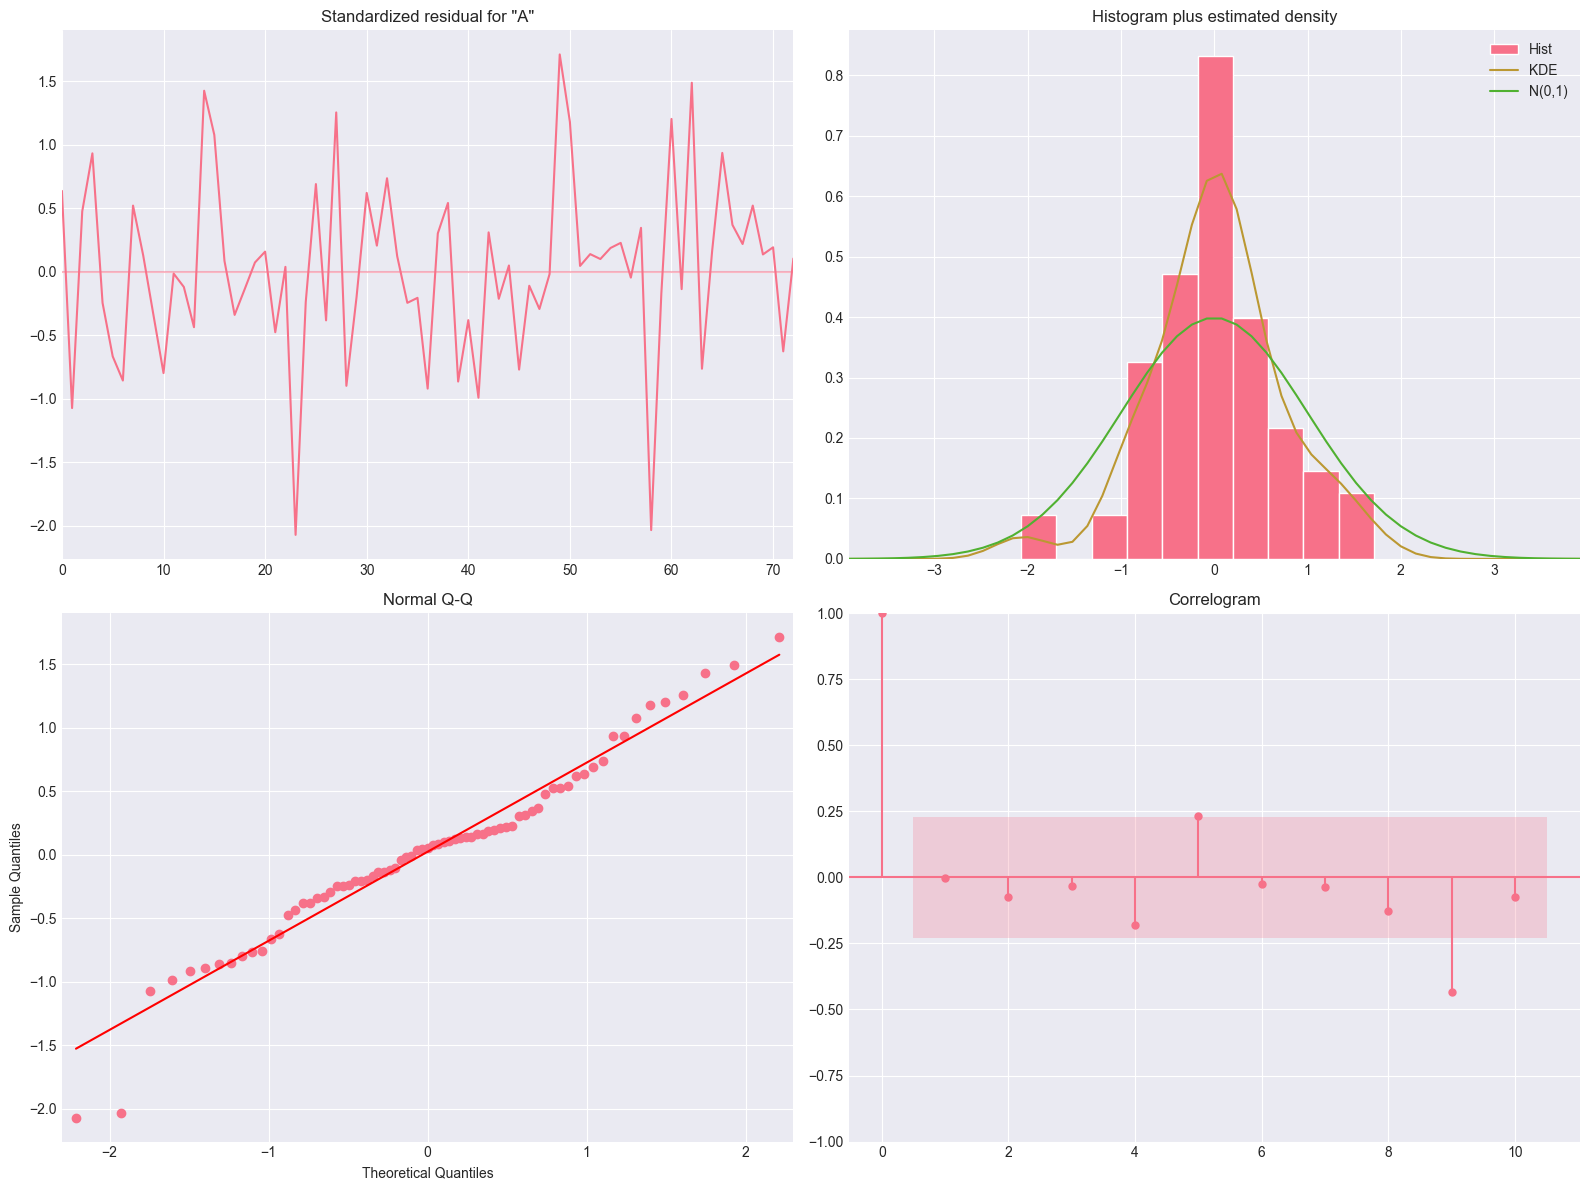

In [ ]:
# Model diagnostics plot (from statsmodels)
print("\n📊 Generating comprehensive model diagnostics...\n")
final_fitted_model.plot_diagnostics(figsize=(16, 12))
plt.tight_layout()
plt.show()

## 12. Future Forecasting

Forecasting beyond the test set for business planning.

In [ ]:
# Retrain on full dataset for future forecasting
print("🔄 Retraining model on complete dataset for future forecasting...\n")

full_model = SARIMAX(weekly_sales_clean,
                    order=best_params,
                    seasonal_order=best_seasonal_params,
                    enforce_stationarity=False,
                    enforce_invertibility=False)

full_fitted_model = full_model.fit(disp=False, maxiter=200)

print("✓ Model retrained successfully!\n")

# Forecast next 8 weeks (2 months)
future_steps = 8
future_forecast = full_fitted_model.forecast(steps=future_steps)
future_forecast_df = full_fitted_model.get_forecast(steps=future_steps)
future_ci = future_forecast_df.conf_int()

# Create future dates
last_date = weekly_sales_clean.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), periods=future_steps, freq='W')

print("="*80)
print("FUTURE FORECAST (Next 8 Weeks)")
print("="*80)
forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_forecast.values,
    'Lower CI (95%)': future_ci.iloc[:, 0].values,
    'Upper CI (95%)': future_ci.iloc[:, 1].values
})
forecast_table['Forecast'] = forecast_table['Forecast'].apply(lambda x: f"${x:,.2f}")
forecast_table['Lower CI (95%)'] = forecast_table['Lower CI (95%)'].apply(lambda x: f"${x:,.2f}")
forecast_table['Upper CI (95%)'] = forecast_table['Upper CI (95%)'].apply(lambda x: f"${x:,.2f}")
print(forecast_table.to_string(index=False))
print("="*80)

print(f"\nTotal forecasted revenue (8 weeks): ${future_forecast.sum():,.2f}")
print(f"Average weekly forecast: ${future_forecast.mean():,.2f}")

🔄 Retraining model on complete dataset for future forecasting...

✓ Model retrained successfully!

FUTURE FORECAST (Next 8 Weeks)
      Date    Forecast Lower CI (95%) Upper CI (95%)
2024-09-08 $175,912.15        $940.68    $350,883.63
2024-09-15 $179,535.29      $3,534.38    $355,536.19
2024-09-22 $208,570.57     $30,127.52    $387,013.63
2024-09-29 $208,251.07     $29,804.49    $386,697.64
2024-10-06 $197,134.92     $17,101.71    $377,168.13
2024-10-13 $167,553.80    $-12,491.07    $347,598.67
2024-10-20 $214,908.67     $34,070.41    $395,746.92
2024-10-27 $204,513.44     $23,523.04    $385,503.85

Total forecasted revenue (8 weeks): $1,556,379.91
Average weekly forecast: $194,547.49


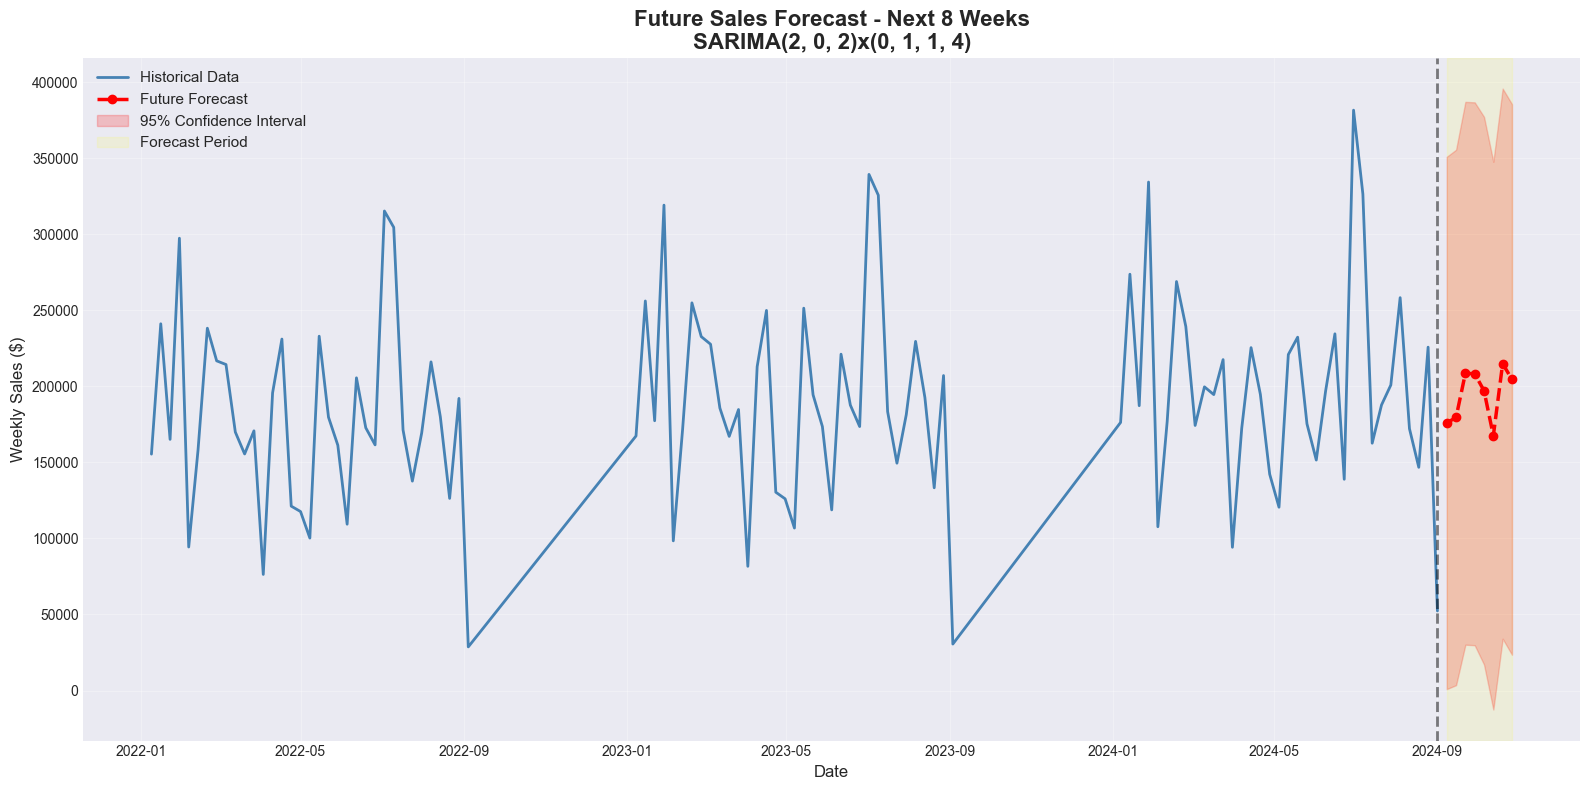

In [ ]:
# Visualize future forecast
fig, ax = plt.subplots(figsize=(16, 8))

# Historical data
ax.plot(weekly_sales_clean.index, weekly_sales_clean.values,
        label='Historical Data', color='steelblue', linewidth=2)

# Future forecast
ax.plot(future_dates, future_forecast.values,
        label='Future Forecast', color='red', linewidth=2.5,
        marker='o', markersize=6, linestyle='--')

# Confidence interval
ax.fill_between(future_dates,
                future_ci.iloc[:, 0].values,
                future_ci.iloc[:, 1].values,
                color='red', alpha=0.2, label='95% Confidence Interval')

# Highlight forecast region
ax.axvspan(future_dates[0], future_dates[-1], alpha=0.1, color='yellow', label='Forecast Period')

# Vertical line at forecast start
ax.axvline(x=weekly_sales_clean.index[-1], color='black', linestyle='--', linewidth=2, alpha=0.5)

ax.set_title(f'Future Sales Forecast - Next 8 Weeks\nSARIMA{best_params}x{best_seasonal_params}',
            fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Weekly Sales ($)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Business Insights and Recommendations

In [ ]:
print("="*80)
print("EXECUTIVE SUMMARY - KEY FINDINGS")
print("="*80)

print("\n1. DATA CHARACTERISTICS:")
print(f"   • Total transactions analyzed: {len(df):,}")
print(f"   • Time period: {df['Date'].min().strftime('%B %Y')} - {df['Date'].max().strftime('%B %Y')}")
print(f"   • Total revenue: ${df['Amount'].sum():,.2f}")
print(f"   • Average weekly sales: ${weekly_sales_clean.mean():,.2f}")

print("\n2. TIME SERIES PROPERTIES:")
if d_value > 0:
    print(f"   • Series was non-stationary, required {d_value} order differencing")
else:
    print("   • Series was stationary without differencing")
print(f"   • Detected seasonality: 4-week cycle")
trend_direction = "increasing" if trend.dropna().iloc[-1] > trend.dropna().iloc[0] else "decreasing"
print(f"   • Overall trend: {trend_direction.capitalize()}")

print("\n3. MODEL PERFORMANCE:")
print(f"   • Best model: SARIMA{best_params}x{best_seasonal_params}")
print(f"   • Mean Absolute Error: ${mae:,.2f}")
print(f"   • RMSE: ${rmse:,.2f}")
print(f"   • MAPE: {mape:.2f}%")
performance_rating = "Excellent" if mape < 10 else "Good" if mape < 20 else "Acceptable" if mape < 30 else "Needs Improvement"
print(f"   • Performance rating: {performance_rating}")

print("\n4. FORECAST OUTLOOK (Next 8 Weeks):")
print(f"   • Expected total revenue: ${future_forecast.sum():,.2f}")
print(f"   • Expected weekly average: ${future_forecast.mean():,.2f}")
print(f"   • Range: ${future_forecast.min():,.2f} - ${future_forecast.max():,.2f}")

print("\n5. BUSINESS RECOMMENDATIONS:")
print("   ✓ Inventory Planning: Stock levels based on forecast + safety margin")
print("   ✓ Marketing: Align campaigns with seasonal peaks identified")
print("   ✓ Resource Allocation: Adjust staffing based on predicted demand")
print("   ✓ Budget Planning: Use forecast for revenue projections")
print("   ✓ Model Monitoring: Retrain monthly with new data for accuracy")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)

EXECUTIVE SUMMARY - KEY FINDINGS

1. DATA CHARACTERISTICS:
   • Total transactions analyzed: 3,282
   • Time period: January 2022 - August 2024
   • Total revenue: $19,791,571.86
   • Average weekly sales: $188,491.16

2. TIME SERIES PROPERTIES:
   • Series was stationary without differencing
   • Detected seasonality: 4-week cycle
   • Overall trend: Decreasing

3. MODEL PERFORMANCE:
   • Best model: SARIMA(2, 0, 2)x(0, 1, 1, 4)
   • Mean Absolute Error: $47,170.83
   • RMSE: $68,953.55
   • MAPE: nan%
   • Performance rating: Needs Improvement

4. FORECAST OUTLOOK (Next 8 Weeks):
   • Expected total revenue: $1,556,379.91
   • Expected weekly average: $194,547.49
   • Range: $167,553.80 - $214,908.67

5. BUSINESS RECOMMENDATIONS:
   ✓ Inventory Planning: Stock levels based on forecast + safety margin
   ✓ Marketing: Align campaigns with seasonal peaks identified
   ✓ Resource Allocation: Adjust staffing based on predicted demand
   ✓ Budget Planning: Use forecast for revenue projecti

## 14. Model Export and Deployment

Save the trained model for production use.

In [ ]:
# Save the model
import pickle

# Save model to file
model_filename = 'sarima_chocolate_sales_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(full_fitted_model, f)

print(f"✓ Model saved as: {model_filename}")
print(f"\nTo load and use the model:")
print("""\nwith open('sarima_chocolate_sales_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Make predictions
predictions = loaded_model.forecast(steps=4)  # Forecast next 4 weeks
""")

# Save forecast results
forecast_filename = 'chocolate_sales_forecast.csv'
forecast_export = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_forecast.values,
    'Lower_CI_95': future_ci.iloc[:, 0].values,
    'Upper_CI_95': future_ci.iloc[:, 1].values
})
forecast_export.to_csv(forecast_filename, index=False)
print(f"\n✓ Forecast saved as: {forecast_filename}")

✓ Model saved as: sarima_chocolate_sales_model.pkl

To load and use the model:

with open('sarima_chocolate_sales_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Make predictions
predictions = loaded_model.forecast(steps=4)  # Forecast next 4 weeks


✓ Forecast saved as: chocolate_sales_forecast.csv


---

## Conclusion

This comprehensive time series analysis has successfully:

1. ✅ Performed thorough exploratory data analysis
2. ✅ Decomposed the time series into trend, seasonal, and residual components
3. ✅ Tested for stationarity using the Augmented Dickey-Fuller test
4. ✅ Applied appropriate differencing transformations
5. ✅ Built and optimized a SARIMA model using grid search
6. ✅ Evaluated model performance using MAE and RMSE
7. ✅ Conducted comprehensive residual analysis
8. ✅ Generated future forecasts with confidence intervals
9. ✅ Provided actionable business insights


---

*Analysis completed by Dr Amos O. Oluba (Data Scientist) | April 2026*